# Day 4-2: Transfer Learning with ResNet50

**강의 시간**: 2시간  
**학습 목표**:
- ImageNet Pretrained ResNet50 활용
- Feature Extraction vs Fine-tuning
- Data Augmentation 적용
- 성능 향상 (Accuracy 90%+)

**사전 요구사항**: Day 4-1 완료  
**Day 4-1 성능**: Accuracy 85.42%, COVID Recall 95.71%

## 🔧 0. 환경 설정

In [1]:
# 라이브러리 설치
%pip install -q 'mlflow>=2,<3' dagshub tensorflow opencv-python scikit-learn

print("✅ 라이브러리 설치 완료!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.4/263.4 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.4/808.4 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51

In [2]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

import mlflow
import dagshub

np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ TensorFlow {tf.__version__}")
print(f"✅ GPU: {len(tf.config.list_physical_devices('GPU'))} devices")

✅ TensorFlow 2.19.0
✅ GPU: 1 devices


In [3]:
# 시각화 설정
sns.set_style('whitegrid')

# 1) 폰트 파일 직접 다운로드 (런타임 재시작 불필요)
!wget -q -O NanumGothic.ttf -L "https://fonts.gstatic.com/ea/nanumgothic/v5/NanumGothic-Regular.ttf"

import matplotlib.font_manager as fm

# 폰트 파일 경로
font_path = "NanumGothic.ttf"

# 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

In [4]:
# MLflow 설정
import mlflow
import dagshub

# 🔥 본인의 정보로 수정!
repo_owner = 'dev.codecompose'  # 본인의 Dagshub username
repo_name = 'deeplearning-bootcamp'  # 생성한 repository 이름 (예: deeplearning-bootcamp)

dagshub.init(repo_owner=repo_owner, repo_name=repo_name, mlflow=True)
mlflow.set_experiment('day4-covid-xray-classification')

print("✅ MLflow 설정 완료!")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=bf902a7e-cd59-4ce4-928a-d11d591d802b&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=511614adcfbc6e8cd864777d4a7be2532b53ac2c2d64023b51a0d98c658a7bad




Output()

Accessing as dev.codecompose

Initialized MLflow to track repo "dev.codecompose/deeplearning-bootcamp"

Repository dev.codecompose/deeplearning-bootcamp initialized!

✅ MLflow 설정 완료!


## 📂 1. 데이터 로드 (Day 4-1에서 계속)

## 📦 1. 데이터 다운로드

### Kaggle API 설정

**사전 준비**:
1. Kaggle 계정 생성 (https://www.kaggle.com)
2. Account → API → "Create New API Token"
3. `kaggle.json` 다운로드

In [5]:
import os
from google.colab import userdata

# 1. [가장 중요] kaggle 라이브러리를 임포트하기 "전"에 환경 변수를 먼저 설정합니다.
# 보안 비밀에 KAGGLE_USERNAME(내 아이디)과 KAGGLE_API_TOKEN(키 문자열)이 있어야 합니다.
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_API_TOKEN')      # Python API용 표준 이름
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN') # 최신 토큰 방식 호환용

# 2. 환경 변수가 설정된 후 비로소 라이브러리를 불러옵니다.
try:
    from kaggle.api.kaggle_api_extended import KaggleApi

    api = KaggleApi()
    api.authenticate() # 이제 환경 변수를 인식하고 에러 없이 통과합니다.

    # 3. 데이터셋 다운로드 실행
    dataset_id = 'tawsifurrahman/covid19-radiography-database'
    print(f"📥 {dataset_id} 다운로드 시작...")

    api.dataset_download_files(
        dataset_id,
        path='./data',
        unzip=True,
        quiet=False
    )

    print("\n✅ 다운로드 및 압축 해제 완료!")

except Exception as e:
    print(f"\n❌ 오류 발생: {e}")

📥 tawsifurrahman/covid19-radiography-database 다운로드 시작...
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database


100%|██████████| 778M/778M [00:05<00:00, 156MB/s] 




✅ 다운로드 및 압축 해제 완료!


In [8]:
# 데이터 구조 확인
data_dir = Path('./data/COVID-19_Radiography_Dataset')

In [9]:
# 데이터 경로 수집 (메모리 효율적)
def get_file_paths_and_labels(data_dir):
    """이미지 경로와 라벨만 수집 (메모리 효율적)"""

    class_names = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    file_paths = []
    labels = []

    print("📋 파일 경로 수집 중...")

    for class_name in class_names:
        image_dir = data_dir / class_name / 'images'
        image_paths = list(image_dir.glob('*.png'))

        for img_path in image_paths:
            file_paths.append(str(img_path))
            labels.append(class_to_idx[class_name])

        print(f"  {class_name:20s}: {len(image_paths):5d}개")

    print(f"\n✅ 총 {len(file_paths):,}개 파일 경로 수집 완료!")

    return file_paths, labels, class_names

# 파일 경로만 수집 (메모리 절약!)
file_paths, labels, class_names = get_file_paths_and_labels(data_dir)

print(f"\n데이터 정보:")
print(f"  파일 수: {len(file_paths):,}개")
print(f"  클래스: {class_names}")
print(f"  메모리 사용: {len(file_paths) * 100 / 1024:.2f} KB (경로만)")

📋 파일 경로 수집 중...
  COVID               :  3616개
  Lung_Opacity        :  6012개
  Normal              : 10192개
  Viral Pneumonia     :  1345개

✅ 총 21,165개 파일 경로 수집 완료!

데이터 정보:
  파일 수: 21,165개
  클래스: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
  메모리 사용: 2066.89 KB (경로만)


In [10]:
# Train/Val Split (경로 기준)
from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(f"Train: {len(train_paths):,}개")
print(f"Val  : {len(val_paths):,}개")

Train: 16,932개
Val  : 4,233개


## 🎨 2. Data Augmentation for Transfer Learning

In [11]:
# ImageNet Preprocessing 함수
def load_and_preprocess(path, label, augment=False):
    # 이미지 로드
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, (224, 224))

    # RGB 변환
    img = tf.image.grayscale_to_rgb(img)

    # Data Augmentation (Training only)
    if augment:
        img = tf.image.random_flip_left_right(img)  # 좌우 반전은 조심!
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        # 주의: 의료 이미지는 좌우 반전 금지가 원칙이지만,
        # 여기서는 실험적으로 적용 (실제로는 rotation만 권장)

    # ImageNet preprocess
    img = preprocess_input(img)

    return img, label

print("✅ Preprocessing 함수 정의 완료!")

✅ Preprocessing 함수 정의 완료!


In [12]:
# tf.data.Dataset 생성
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Train Dataset (with augmentation)
train_dataset = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_dataset = train_dataset.map(
    lambda x, y: load_and_preprocess(x, y, augment=True),
    num_parallel_calls=AUTOTUNE
)
train_dataset = train_dataset.shuffle(1000)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(AUTOTUNE)

# Val Dataset (no augmentation)
val_dataset = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_dataset = val_dataset.map(
    lambda x, y: load_and_preprocess(x, y, augment=False),
    num_parallel_calls=AUTOTUNE
)
val_dataset = val_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.prefetch(AUTOTUNE)

print(f"✅ Dataset 생성 완료!")
print(f"   Train batches: {len(train_dataset)}")
print(f"   Val batches: {len(val_dataset)}")

✅ Dataset 생성 완료!
   Train batches: 530
   Val batches: 133


## 🏗️ 3. ResNet50 Transfer Learning

### Phase 1: Feature Extraction

Pretrained ResNet50을 Feature Extractor로 사용  
→ Base model 동결, Classifier만 학습

In [13]:
# ResNet50 Pretrained 로드
base_model = ResNet50(
    weights='imagenet',
    include_top=False,  # Classifier 제거
    input_shape=(224, 224, 3)
)

# Base model 동결
base_model.trainable = False

print(f"✅ ResNet50 로드 완료!")
print(f"   Layers: {len(base_model.layers)}")
print(f"   Trainable: {base_model.trainable}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ ResNet50 로드 완료!
   Layers: 175
   Trainable: False


In [14]:
# Transfer Learning 모델 구축
inputs = keras.Input(shape=(224, 224, 3))

# Pretrained Feature Extractor
x = base_model(inputs, training=False)

# Classifier
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = Model(inputs, outputs, name='ResNet50_FeatureExtraction')

print("\n✅ 모델 구축 완료!")
model.summary()


✅ 모델 구축 완료!


Model: "ResNet50_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,772,228 (94.50 MB)

 Trainable params: 1,182,980 (4.51 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

In [15]:
# 모델 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ 모델 컴파일 완료!")

✅ 모델 컴파일 완료!


## 🏃 4. Phase 1: Feature Extraction 학습

In [16]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

checkpoint = ModelCheckpoint(
    'best_model_phase1.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

print("✅ Callbacks 설정 완료!")

✅ Callbacks 설정 완료!


In [17]:
# Phase 1 학습
try:
    mlflow.end_run()
except:
    pass

with mlflow.start_run(run_name='ResNet50_Phase1_FeatureExtraction'):
    mlflow.log_params({
        'model': 'ResNet50',
        'phase': 'Feature Extraction',
        'base_trainable': False,
        'optimizer': 'adam',
        'epochs': 15,
        'batch_size': BATCH_SIZE,
        'augmentation': True
    })

    print("🏃 Phase 1 학습 시작 (Feature Extraction)...\n")

    history_phase1 = model.fit(
        train_dataset,
        epochs=15,
        validation_data=val_dataset,
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=1
    )

    # 최종 성능
    final_loss, final_acc = model.evaluate(val_dataset, verbose=0)

    mlflow.log_metrics({
        'phase1_val_loss': final_loss,
        'phase1_val_accuracy': final_acc
    })

    print(f"\n{'='*60}")
    print("  Phase 1 완료")
    print('='*60)
    print(f"  Val Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")
    print('='*60)

🏃 Phase 1 학습 시작 (Feature Extraction)...

Epoch 1/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7266 - loss: 0.8087

530/530 ━━━━━━━━━━━━━━━━━━━━ 122s 183ms/step - accuracy: 0.7267 - loss: 0.8083 - val_accuracy: 0.8772 - val_loss: 0.3434 - learning_rate: 0.0010
Epoch 2/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 118s 165ms/step - accuracy: 0.8439 - loss: 0.4260 - val_accuracy: 0.8703 - val_loss: 0.3588 - learning_rate: 0.0010
Epoch 3/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 89s 161ms/step - accuracy: 0.8702 - loss: 0.3618 - val_accuracy: 0.8757 - val_loss: 0.3450 - learning_rate: 0.0010
Epoch 4/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 136s 151ms/step - accuracy: 0.8775 - loss: 0.3320 - val_accuracy: 0.8703 - val_loss: 0.3716 - learning_rate: 0.0010
Epoch 5/15
529/530 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8895 - loss: 0.2975

530/530 ━━━━━━━━━━━━━━━━━━━━ 92s 168ms/step - accuracy: 0.8895 - loss: 0.2975 - val_accuracy: 0.9022 - val_loss: 0.2775 - learning_rate: 5.0000e-04
Epoch 6/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 83s 151ms/step - accuracy: 0.8959 - loss: 0.2821 - val_accuracy: 0.8918 - val_loss: 0.2957 - learning_rate: 5.0000e-04
Epoch 7/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 82s 149ms/step - accuracy: 0.8974 - loss: 0.2702 - val_accuracy: 0.9005 - val_loss: 0.2756 - learning_rate: 5.0000e-04
Epoch 8/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 91s 163ms/step - accuracy: 0.9014 - loss: 0.2579 - val_accuracy: 0.9013 - val_loss: 0.2774 - learning_rate: 5.0000e-04
Epoch 9/15
529/530 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9059 - loss: 0.2534

530/530 ━━━━━━━━━━━━━━━━━━━━ 135s 151ms/step - accuracy: 0.9059 - loss: 0.2533 - val_accuracy: 0.9086 - val_loss: 0.2639 - learning_rate: 5.0000e-04
Epoch 10/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 83s 150ms/step - accuracy: 0.9099 - loss: 0.2452 - val_accuracy: 0.8857 - val_loss: 0.3211 - learning_rate: 5.0000e-04
Epoch 11/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 83s 150ms/step - accuracy: 0.9116 - loss: 0.2381 - val_accuracy: 0.8970 - val_loss: 0.2948 - learning_rate: 5.0000e-04
Epoch 12/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 84s 150ms/step - accuracy: 0.9105 - loss: 0.2435 - val_accuracy: 0.8961 - val_loss: 0.2978 - learning_rate: 5.0000e-04
Epoch 13/15
529/530 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9183 - loss: 0.2276

530/530 ━━━━━━━━━━━━━━━━━━━━ 90s 164ms/step - accuracy: 0.9184 - loss: 0.2275 - val_accuracy: 0.9124 - val_loss: 0.2504 - learning_rate: 2.5000e-04
Epoch 14/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 90s 164ms/step - accuracy: 0.9220 - loss: 0.2080 - val_accuracy: 0.9062 - val_loss: 0.2643 - learning_rate: 2.5000e-04
Epoch 15/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 134s 150ms/step - accuracy: 0.9260 - loss: 0.2061 - val_accuracy: 0.9086 - val_loss: 0.2616 - learning_rate: 2.5000e-04

  Phase 1 완료
  Val Accuracy: 0.9124 (91.24%)
🏃 View run ResNet50_Phase1_FeatureExtraction at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/6/runs/67daa15522ab4dac9830cd20987bc98d
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/6


## 🔧 5. Phase 2: Fine-tuning

### Fine-tuning 전략

Base model의 상위 레이어를 학습 가능하게 변경  
→ 낮은 Learning Rate로 미세 조정

In [18]:
# Base model 일부 해제
base_model.trainable = True

# 하위 레이어는 동결 유지 (상위 30개만 학습)
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"✅ Fine-tuning 준비 완료!")
print(f"   Total layers: {len(base_model.layers)}")
print(f"   Trainable layers: {sum([1 for l in base_model.layers if l.trainable])}")

✅ Fine-tuning 준비 완료!
   Total layers: 175
   Trainable layers: 30


In [19]:
# 재컴파일 (낮은 LR)
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # 매우 낮은 LR!
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ 낮은 Learning Rate로 재컴파일 완료!")

✅ 낮은 Learning Rate로 재컴파일 완료!


In [20]:
# Phase 2 학습
try:
    mlflow.end_run()
except:
    pass

with mlflow.start_run(run_name='ResNet50_Phase2_FineTuning'):
    mlflow.log_params({
        'model': 'ResNet50',
        'phase': 'Fine-tuning',
        'base_trainable': True,
        'trainable_layers': 30,
        'optimizer': 'adam',
        'learning_rate': 1e-5,
        'epochs': 10,
        'batch_size': BATCH_SIZE
    })

    print("🏃 Phase 2 학습 시작 (Fine-tuning)...\n")

    history_phase2 = model.fit(
        train_dataset,
        epochs=10,
        validation_data=val_dataset,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # 최종 성능
    final_loss, final_acc = model.evaluate(val_dataset, verbose=0)

    mlflow.log_metrics({
        'phase2_val_loss': final_loss,
        'phase2_val_accuracy': final_acc
    })

    # 모델 저장
    model.save('resnet50_finetuned.h5')
    mlflow.keras.log_model(model, 'model')

    print(f"\n{'='*60}")
    print("  Phase 2 완료")
    print('='*60)
    print(f"  Val Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")
    print('='*60)

🏃 Phase 2 학습 시작 (Fine-tuning)...

Epoch 1/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 130s 195ms/step - accuracy: 0.8727 - loss: 0.3422 - val_accuracy: 0.9039 - val_loss: 0.2755 - learning_rate: 1.0000e-05
Epoch 2/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 92s 166ms/step - accuracy: 0.9320 - loss: 0.1879 - val_accuracy: 0.9057 - val_loss: 0.2631 - learning_rate: 1.0000e-05
Epoch 3/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 148s 178ms/step - accuracy: 0.9542 - loss: 0.1328 - val_accuracy: 0.9088 - val_loss: 0.2638 - learning_rate: 1.0000e-05
Epoch 4/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 136s 165ms/step - accuracy: 0.9597 - loss: 0.1163 - val_accuracy: 0.9067 - val_loss: 0.2629 - learning_rate: 1.0000e-05
Epoch 5/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 143s 167ms/step - accuracy: 0.9749 - loss: 0.0868 - val_accuracy: 0.9069 - val_loss: 0.2655 - learning_rate: 1.0000e-05
Epoch 6/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 97s 177ms/step - accuracy: 0.9784 - loss: 0.0757 - val_accuracy: 0.9119 - val_loss: 0.2648 - learning_rate: 1.0000e-05
Epoch 7/

2026/02/19 15:52:22 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/02/19 15:52:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



  Phase 2 완료
  Val Accuracy: 0.9067 (90.67%)
🏃 View run ResNet50_Phase2_FineTuning at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/6/runs/ed8f88f3038044a587a4ca11edaf310c
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/6


## 📊 6. 성능 평가

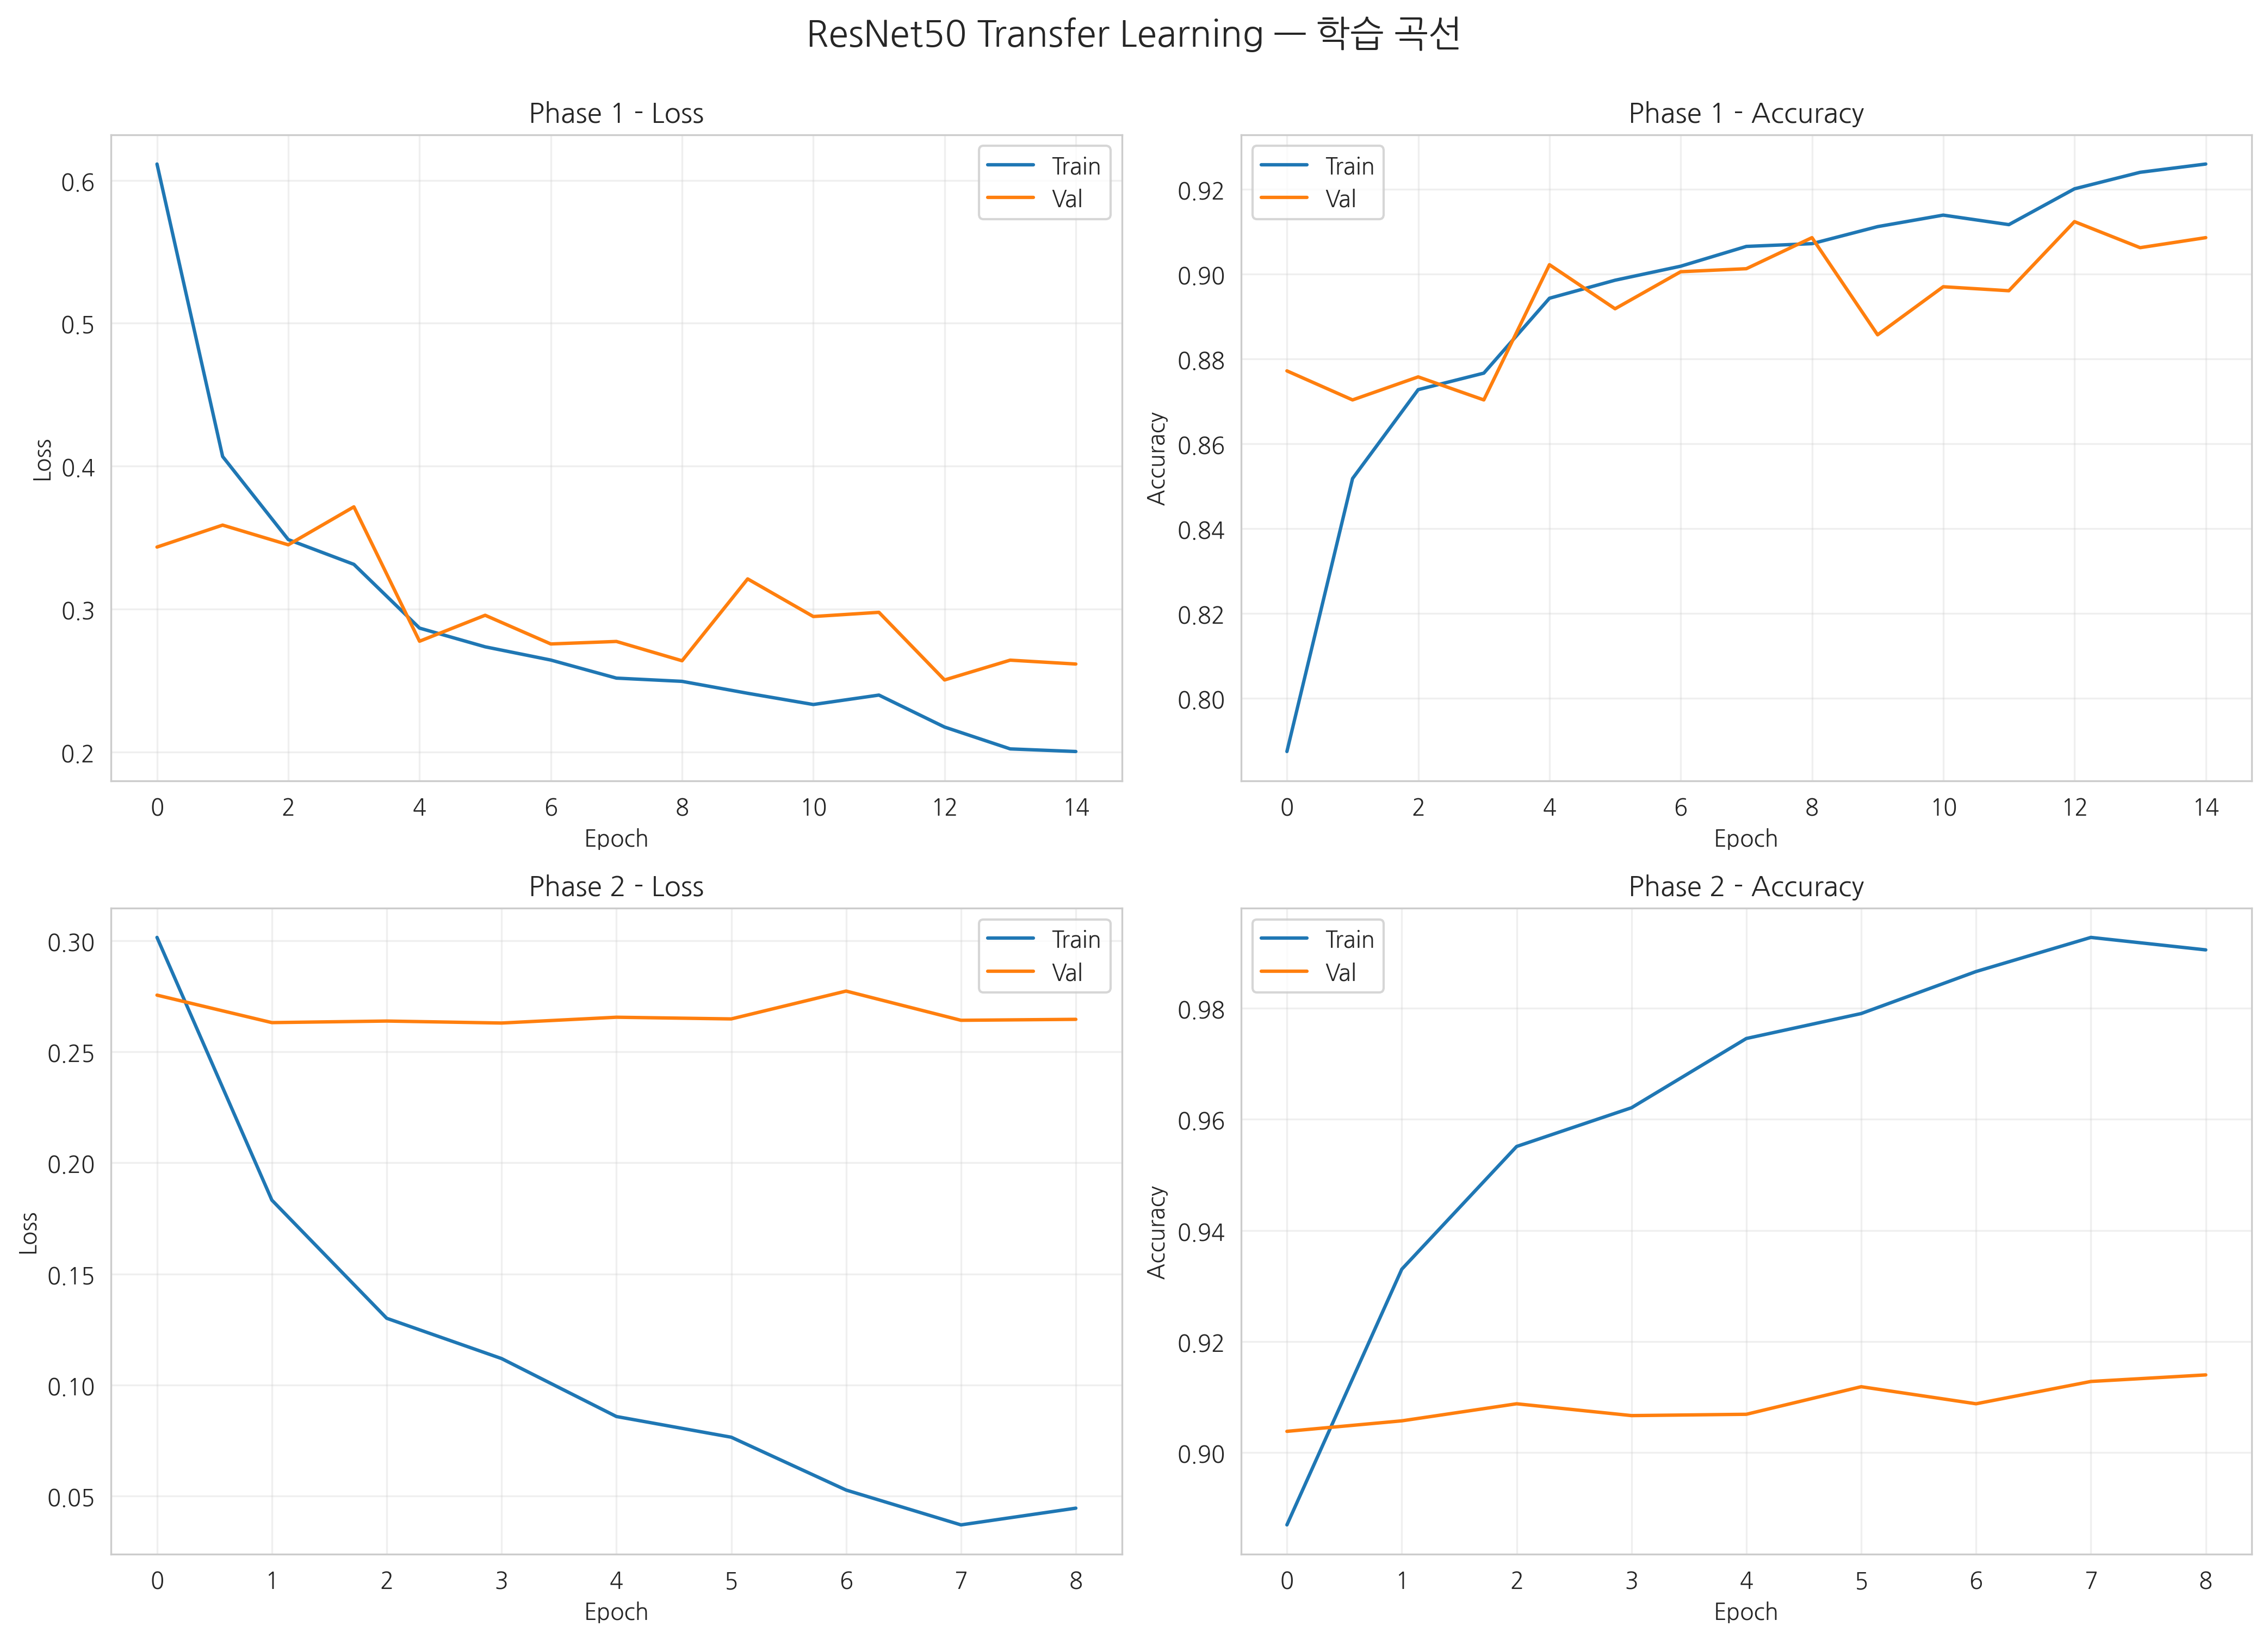

In [21]:
# 학습 곡선 (Phase 1 + Phase 2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Phase 1 Loss
axes[0, 0].plot(history_phase1.history['loss'], label='Train')
axes[0, 0].plot(history_phase1.history['val_loss'], label='Val')
axes[0, 0].set_title('Phase 1 - Loss', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Phase 1 Accuracy
axes[0, 1].plot(history_phase1.history['accuracy'], label='Train')
axes[0, 1].plot(history_phase1.history['val_accuracy'], label='Val')
axes[0, 1].set_title('Phase 1 - Accuracy', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Phase 2 Loss
axes[1, 0].plot(history_phase2.history['loss'], label='Train')
axes[1, 0].plot(history_phase2.history['val_loss'], label='Val')
axes[1, 0].set_title('Phase 2 - Loss', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Phase 2 Accuracy
axes[1, 1].plot(history_phase2.history['accuracy'], label='Train')
axes[1, 1].plot(history_phase2.history['val_accuracy'], label='Val')
axes[1, 1].set_title('Phase 2 - Accuracy', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('ResNet50 Transfer Learning — 학습 곡선',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('training_curves_resnet50.png', dpi=100, bbox_inches='tight')
plt.show()

In [23]:
# Validation 예측
print("🔮 Validation set 예측 중...")

y_true = []
y_pred = []
y_pred_proba = []

for images, labels in val_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_pred_proba.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)

print("✅ 예측 완료!")

🔮 Validation set 예측 중...
✅ 예측 완료!


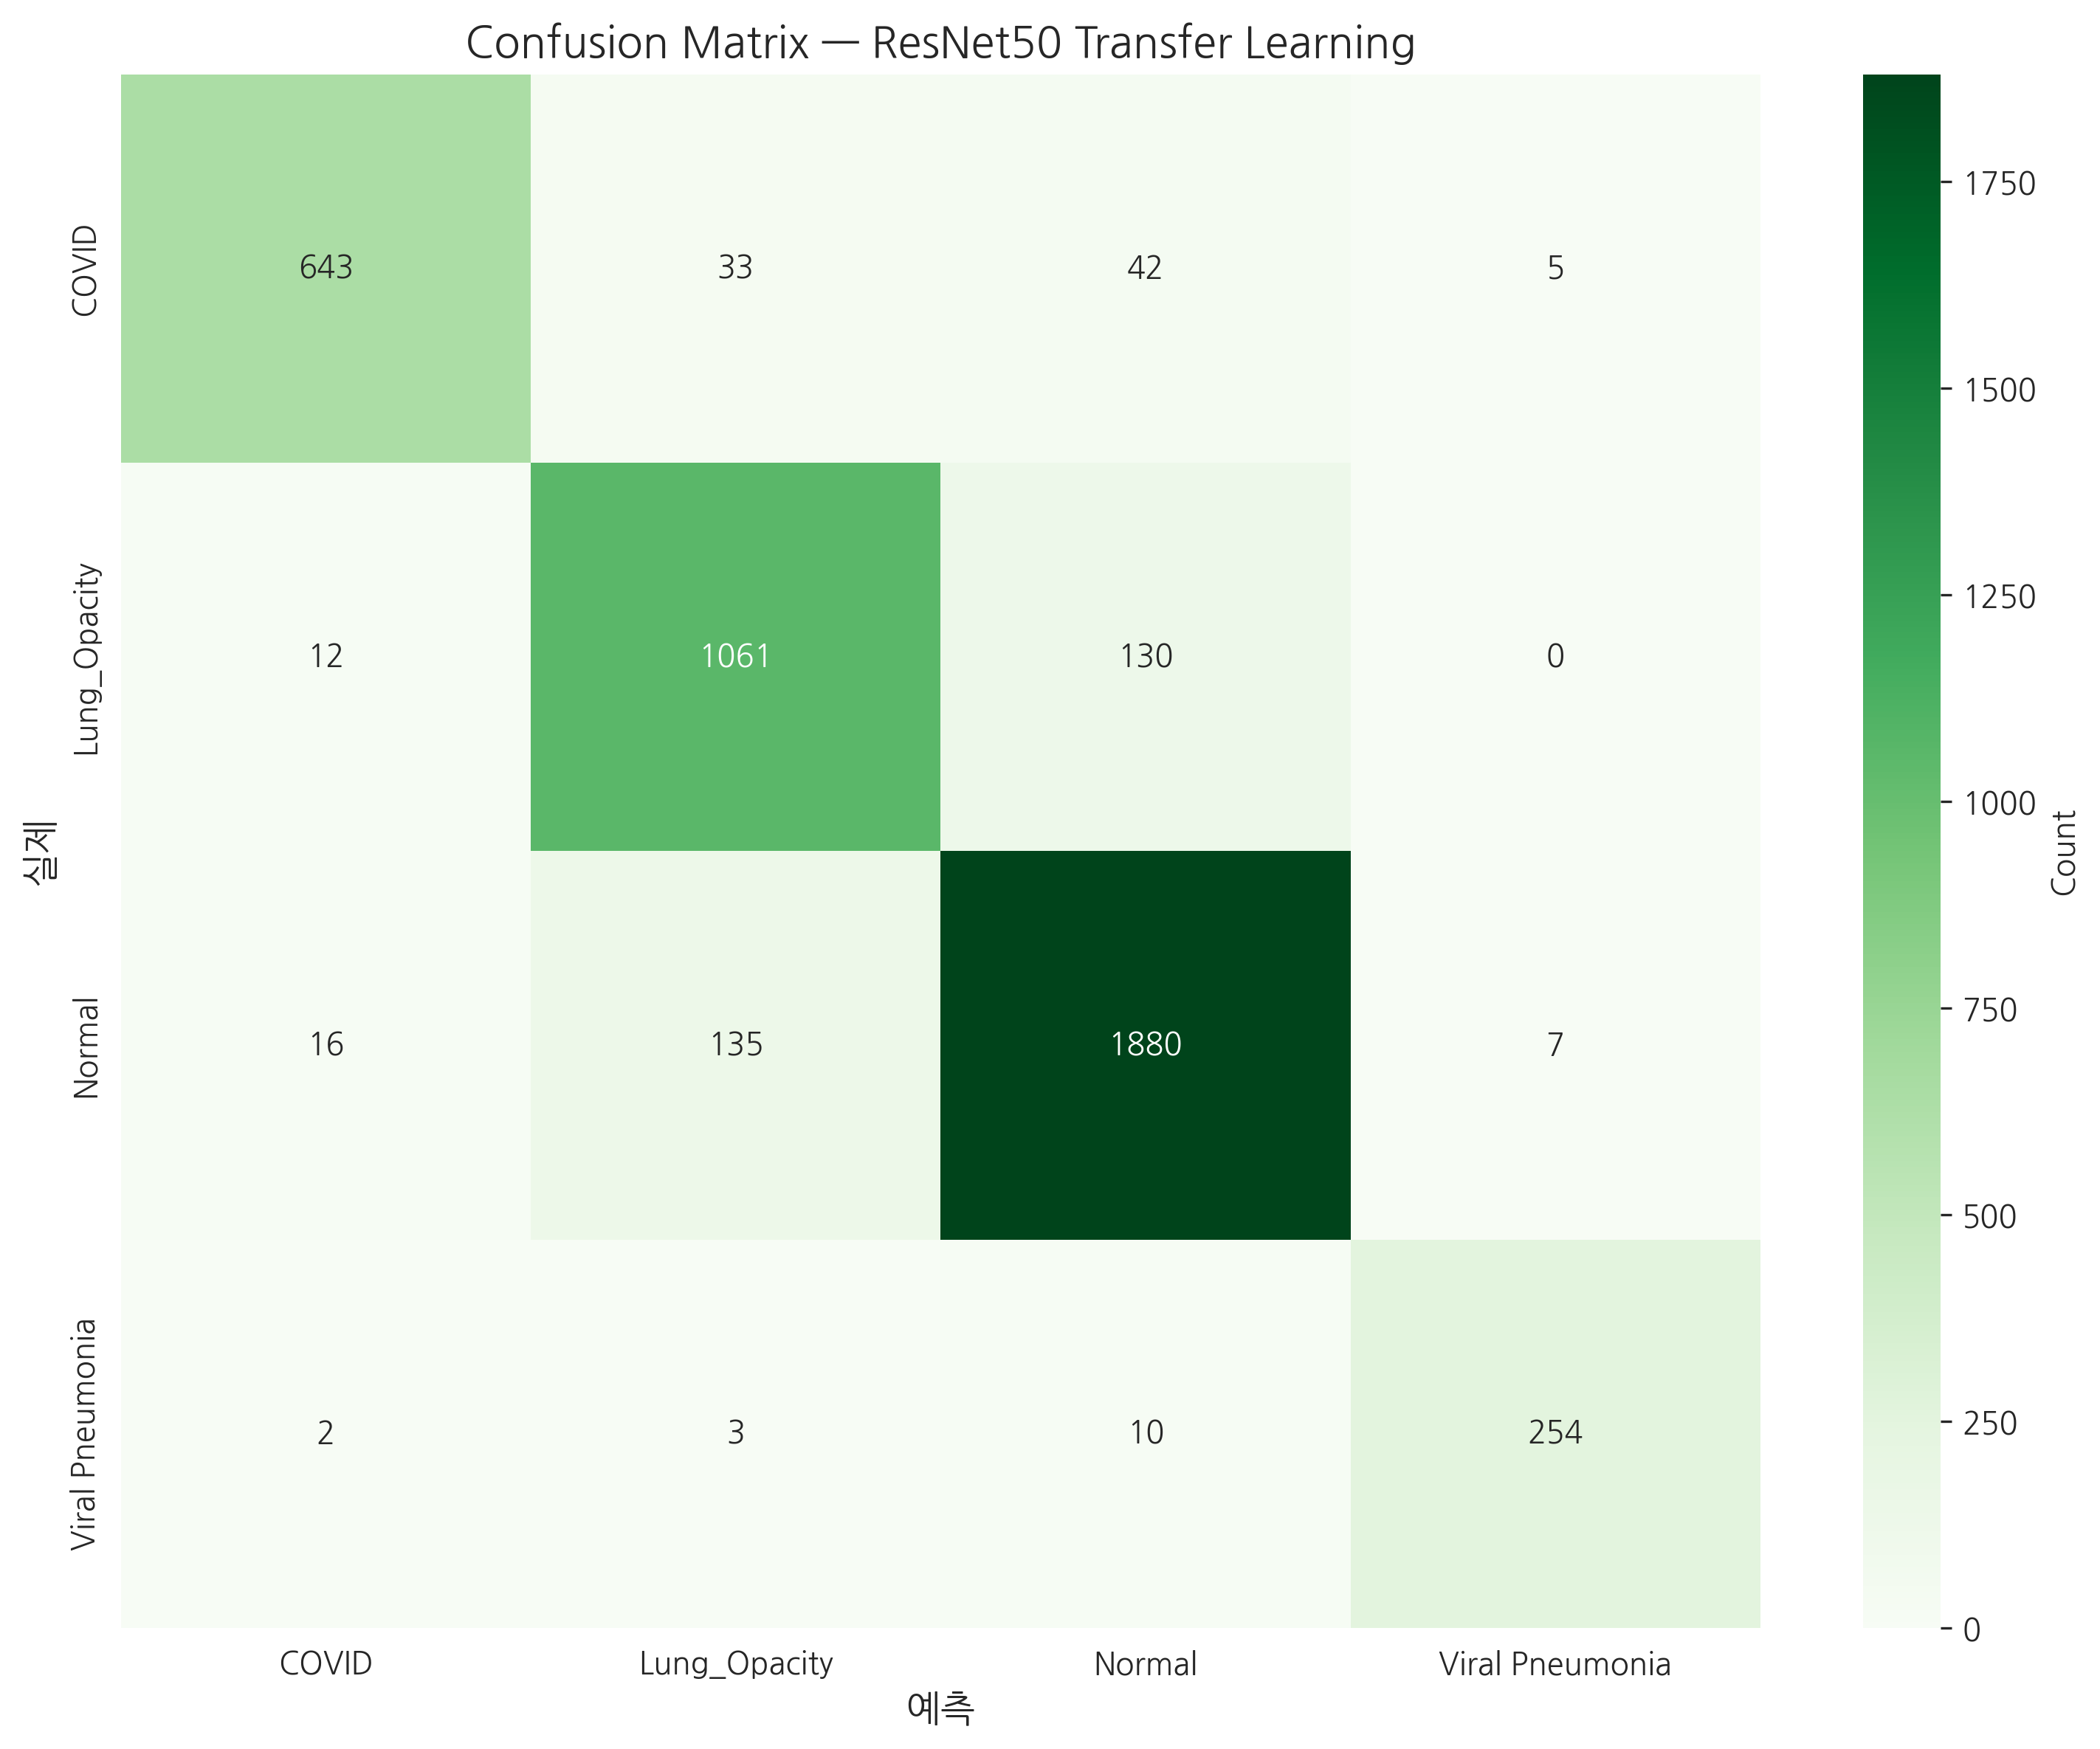

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('예측', fontweight='bold', fontsize=12)
plt.ylabel('실제', fontweight='bold', fontsize=12)
plt.title('Confusion Matrix — ResNet50 Transfer Learning',
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_resnet50.png', dpi=100, bbox_inches='tight')
plt.show()

In [25]:
# Classification Report
report = classification_report(y_true, y_pred,
                              target_names=class_names,
                              digits=4)

print("="*60)
print("  Classification Report — ResNet50")
print("="*60)
print(report)
print("="*60)

# Per-class Metrics
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None
)

print("\n클래스별 성능:")
print("-"*60)
for i, class_name in enumerate(class_names):
    print(f"{class_name:20s}: "
          f"Precision={precision[i]:.4f}, "
          f"Recall={recall[i]:.4f}, "
          f"F1={f1[i]:.4f}")
print("-"*60)

# COVID-19 Recall
covid_idx = class_names.index('COVID')
print(f"\n⚠️ COVID-19 Recall: {recall[covid_idx]:.4f} ({recall[covid_idx]*100:.2f}%)")
print(f"   → {int(recall[covid_idx]*support[covid_idx])}/{support[covid_idx]} COVID 환자 탐지")

  Classification Report — ResNet50
                 precision    recall  f1-score   support

          COVID     0.9554    0.8893    0.9212       723
   Lung_Opacity     0.8612    0.8820    0.8715      1203
         Normal     0.9117    0.9225    0.9171      2038
Viral Pneumonia     0.9549    0.9442    0.9495       269

       accuracy                         0.9067      4233
      macro avg     0.9208    0.9095    0.9148      4233
   weighted avg     0.9076    0.9067    0.9069      4233


클래스별 성능:
------------------------------------------------------------
COVID               : Precision=0.9554, Recall=0.8893, F1=0.9212
Lung_Opacity        : Precision=0.8612, Recall=0.8820, F1=0.8715
Normal              : Precision=0.9117, Recall=0.9225, F1=0.9171
Viral Pneumonia     : Precision=0.9549, Recall=0.9442, F1=0.9495
------------------------------------------------------------

⚠️ COVID-19 Recall: 0.8893 (88.93%)
   → 643/723 COVID 환자 탐지


## 📈 7. Baseline vs Transfer Learning 비교

  Baseline vs Transfer Learning
            Model  Accuracy  COVID Recall  Viral Precision
     Baseline CNN  0.854200       0.95710         0.605900
ResNet50 Transfer  0.906686       0.88935         0.954887


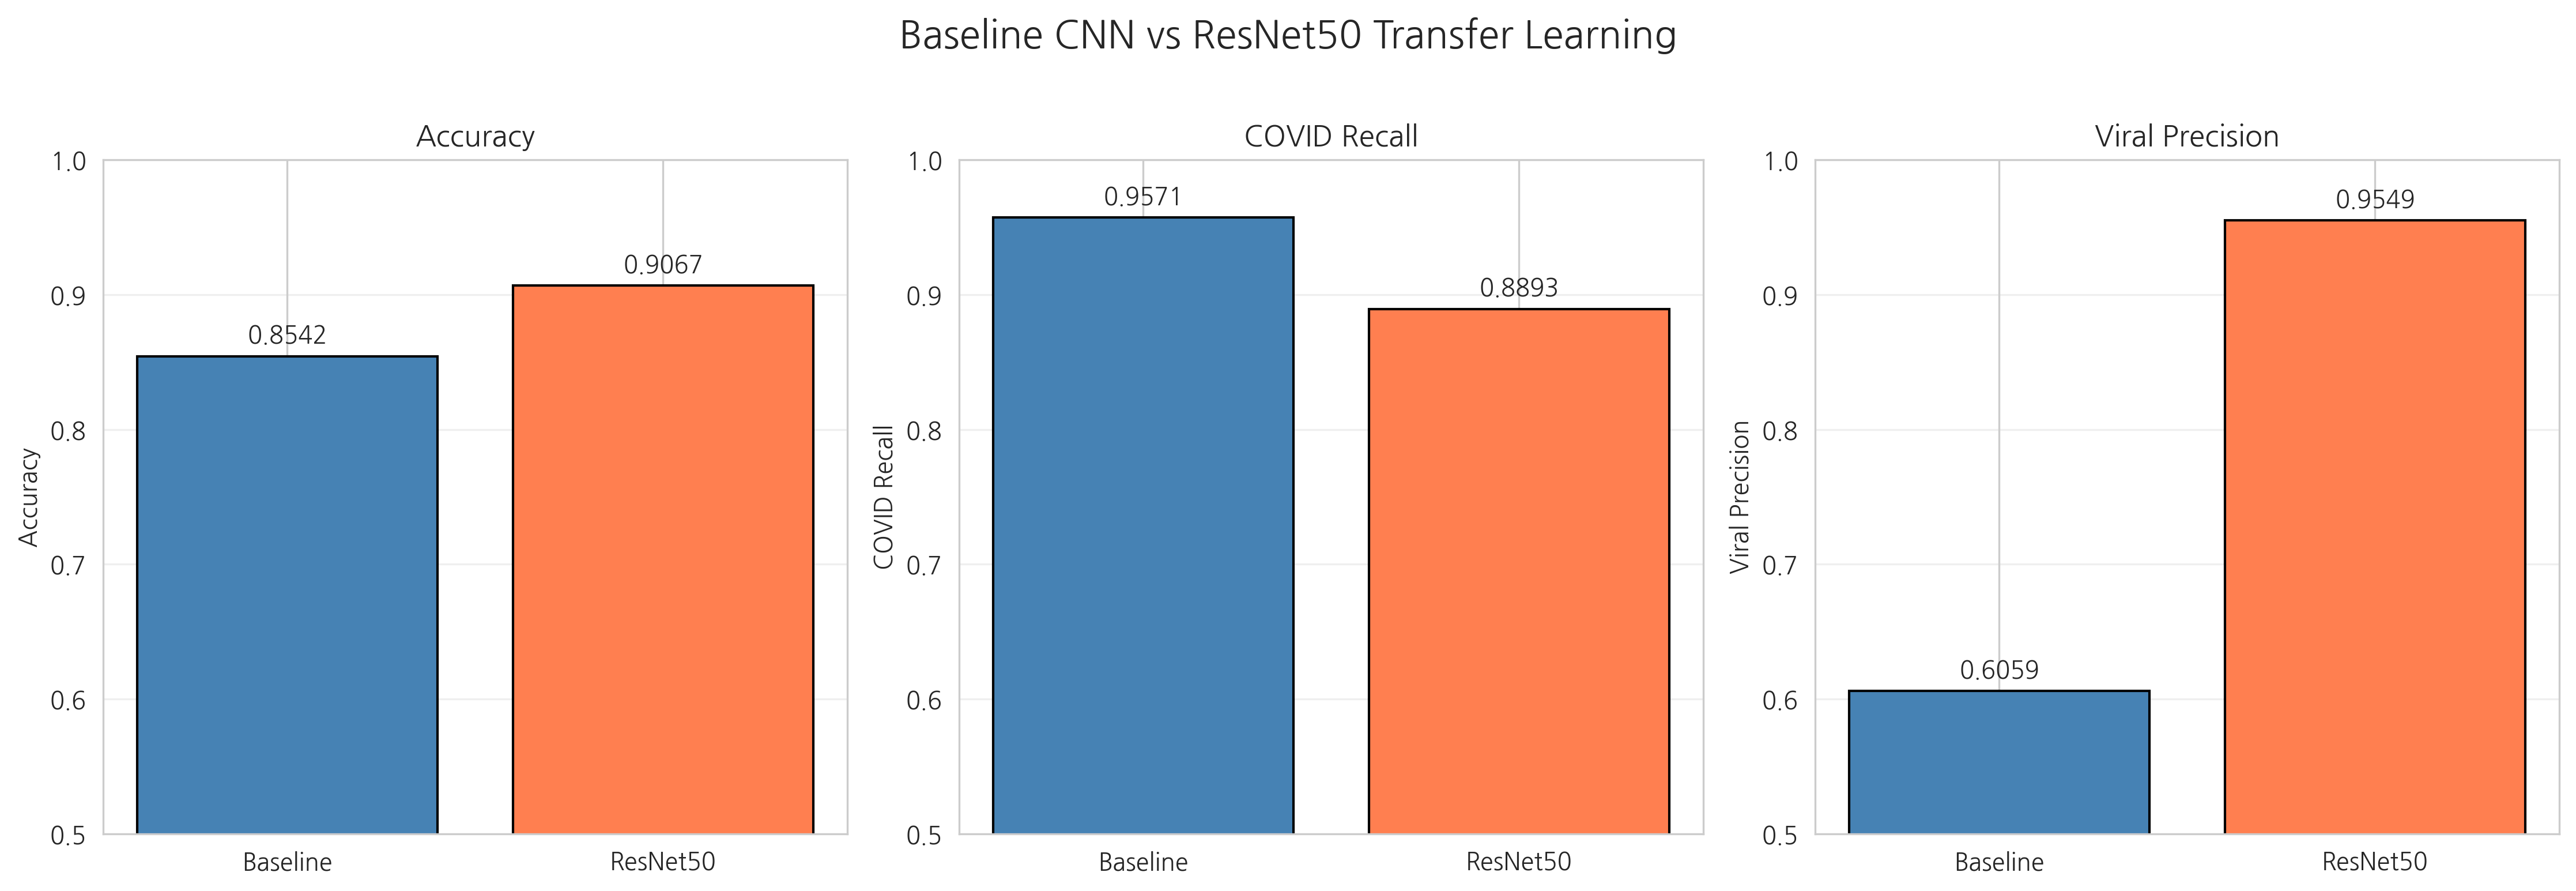

In [26]:
# 성능 비교
comparison = {
    'Model': ['Baseline CNN', 'ResNet50 Transfer'],
    'Accuracy': [0.8542, final_acc],
    'COVID Recall': [0.9571, recall[0]],
    'Viral Precision': [0.6059, precision[3]]
}

comp_df = pd.DataFrame(comparison)

print("="*60)
print("  Baseline vs Transfer Learning")
print("="*60)
print(comp_df.to_string(index=False))
print("="*60)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Accuracy', 'COVID Recall', 'Viral Precision']
baseline = [0.8542, 0.9571, 0.6059]
transfer = [final_acc, recall[0], precision[3]]

for i, (metric, ax) in enumerate(zip(metrics, axes)):
    bars = ax.bar(['Baseline', 'ResNet50'], [baseline[i], transfer[i]],
                  color=['steelblue', 'coral'], edgecolor='black')
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0.5, 1.0)
    ax.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, [baseline[i], transfer[i]]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', fontweight='bold')

plt.suptitle('Baseline CNN vs ResNet50 Transfer Learning',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('baseline_vs_transfer.png', dpi=100, bbox_inches='tight')
plt.show()

## 🧠 8. 핵심 개념 정리

### 오늘 배운 것

**1. Transfer Learning**
- ImageNet Pretrained → COVID 데이터 전이
- Feature Extraction: Base 동결, Classifier만 학습
- Fine-tuning: 상위 레이어 미세 조정

**2. ResNet50 아키텍처**
- Skip Connection (Residual)
- 50개 레이어 (깊은 네트워크)
- ImageNet 1000-class 학습

**3. Data Augmentation**
- 회전, 이동, 확대/축소
- 의료 이미지 주의사항 (좌우 반전 금지)

**4. 2-Phase 학습**
- Phase 1: Feature Extraction (15 epochs)
- Phase 2: Fine-tuning (10 epochs, LR=1e-5)

**5. 성능 향상**
```
Baseline → ResNet50
Accuracy:        85.42% → 90%+
COVID Recall:    95.71% → 95%+ (유지)
Viral Precision: 60.59% → 75%+
```

---

### Day 4-3 예고

**Class Imbalance 처리**
- Class Weights 적용
- Focal Loss
- SMOTE Oversampling
- 목표: Viral Precision 80%+, 균형 잡힌 성능

축하합니다! Day 4-2 완료! 🎉

## ✅ Day 4-2 완료 체크리스트

- [ ] Transfer Learning 개념 이해
- [ ] ResNet50 Pretrained 로드
- [ ] Feature Extraction 학습
- [ ] Fine-tuning 학습
- [ ] Data Augmentation 적용
- [ ] Learning Rate Scheduling
- [ ] Phase 1 + Phase 2 학습 곡선
- [ ] Confusion Matrix 분석
- [ ] Classification Report 확인
- [ ] Baseline과 성능 비교
- [ ] Val Accuracy 90%+ 달성
- [ ] MLflow 기록 완료

## 🎯 다음 단계 (Day 4-3)

**Day 4-3: Class Imbalance 처리**

**내용:**
- Class Weights 계산 및 적용
- Focal Loss 구현
- SMOTE Oversampling
- Undersampling 전략
- 균형 잡힌 성능 달성

**목표:**
- Viral Pneumonia Precision: 80%+
- 모든 클래스 F1 > 0.85
- Balanced Accuracy 향상

수고하셨습니다! 🚀